# Clustering — Análise Exploratória (EDA)
**Pergunta:** Quais perfis de trabalhadores estão mais vulneráveis à IA?

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

df = pd.read_csv('../dataset/ai_job_impact.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (2000, 17)


,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03


## 1. Visão Geral

In [5]:
print(df.dtypes)
print('\nNulos por coluna:')
print(df.isnull().sum())
df.describe().T

Employee_ID                  str
Age                        int64
Gender                       str
Education_Level              str
Industry                     str
Job_Role                     str
Years_Experience           int64
AI_Adoption_Level            str
Automation_Risk              str
Upskilling_Required          str
Salary_Before_AI           int64
Salary_After_AI            int64
Job_Status                   str
Work_Hours_Per_Week        int64
Remote_Work                  str
Job_Satisfaction           int64
Productivity_Change_%    float64
dtype: object

Nulos por coluna:
Employee_ID              0
Age                      0
Gender                   0
Education_Level          0
Industry                 0
Job_Role                 0
Years_Experience         0
AI_Adoption_Level        0
Automation_Risk          0
Upskilling_Required      0
Salary_Before_AI         0
Salary_After_AI          0
Job_Status               0
Work_Hours_Per_Week      0
Remote_Work              0
J

,count,mean,std,min,25%,50%,75%,max
Age,2000.0,40.55800,10.786418,22.00,32.000,40.00,50.0000,59.00
Years_Experience,2000.0,16.66350,10.746675,0.00,8.000,16.00,26.0000,37.00
Salary_Before_AI,2000.0,73942.07250,26055.823793,30036.00,51665.500,74620.00,95418.2500,119976.00
Salary_After_AI,2000.0,78428.64250,29351.599013,24447.00,54086.750,76820.50,100730.2500,161745.00
Work_Hours_Per_Week,2000.0,44.85100,5.712540,35.00,40.000,45.00,50.0000,54.00
Job_Satisfaction,2000.0,6.02050,2.006263,3.00,4.000,6.00,8.0000,9.00
Productivity_Change_%,2000.0,9.78582,17.187882,-19.99,-5.355,9.85,24.5825,39.99


## 2. Distribuição das variáveis numéricas

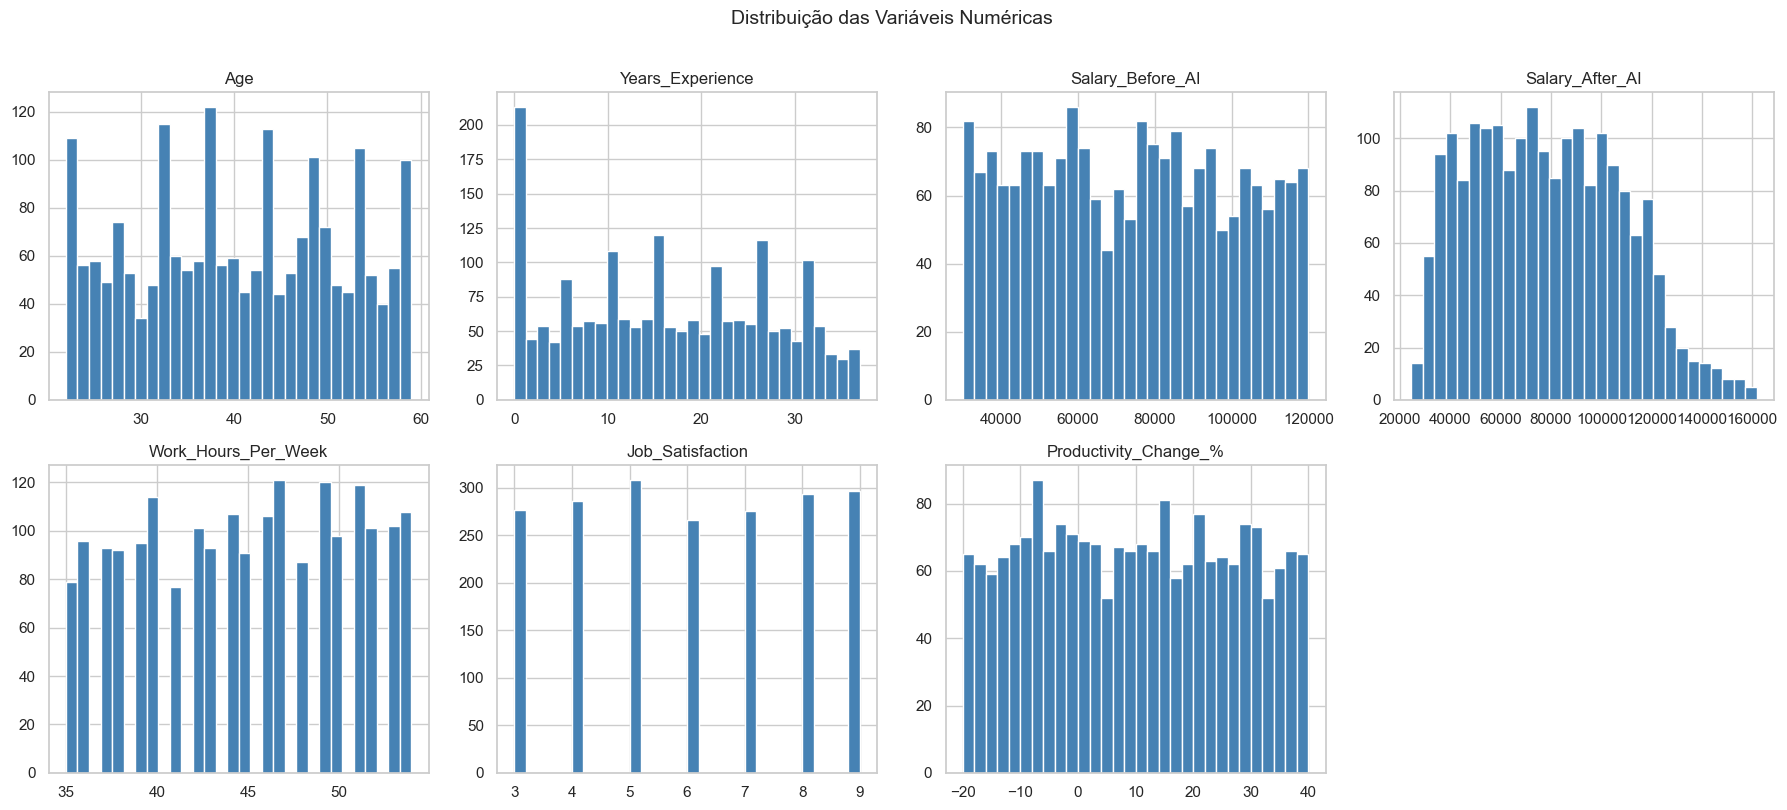

In [6]:
num_cols = ['Age', 'Years_Experience', 'Salary_Before_AI', 'Salary_After_AI',
            'Work_Hours_Per_Week', 'Job_Satisfaction', 'Productivity_Change_%']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, edgecolor='white', color='steelblue')
    axes[i].set_title(col)

axes[-1].set_visible(False)
plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Distribuição das variáveis categóricas

/var/folders/bp/vgg7l59507d7qlq8jzdh7_rw0000gn/T/ipykernel_68149/1973898161.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=ordem, ax=axes[i], palette='Set2')
/var/folders/bp/vgg7l59507d7qlq8jzdh7_rw0000gn/T/ipykernel_68149/1973898161.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=ordem, ax=axes[i], palette='Set2')
/var/folders/bp/vgg7l59507d7qlq8jzdh7_rw0000gn/T/ipykernel_68149/1973898161.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=ordem, ax=axes[i], pa

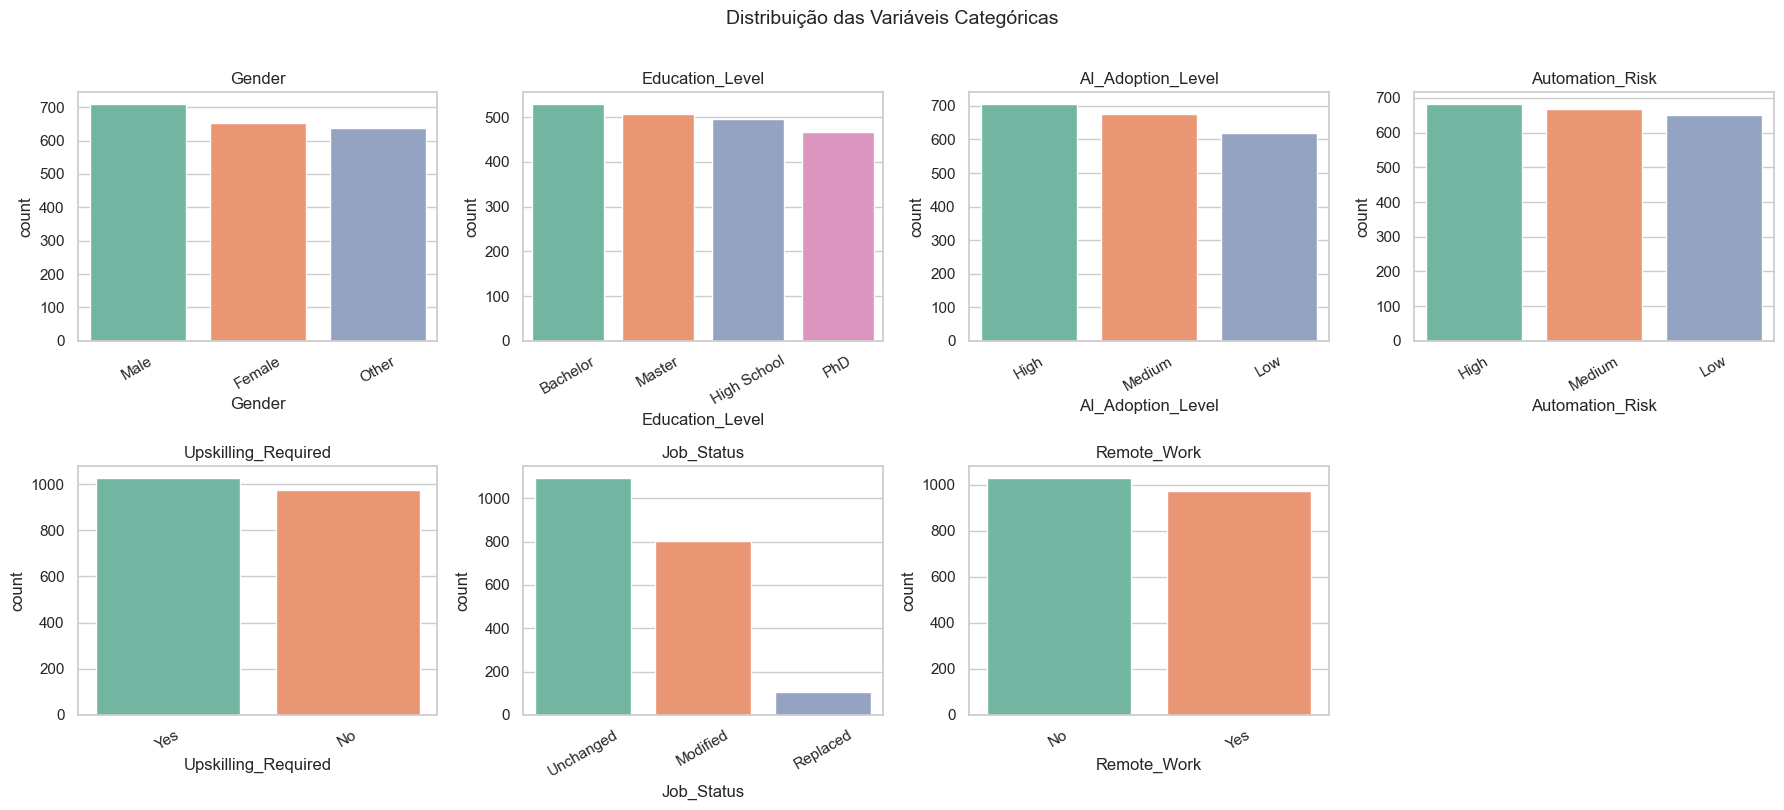

In [7]:
cat_cols = ['Gender', 'Education_Level', 'AI_Adoption_Level',
            'Automation_Risk', 'Upskilling_Required', 'Job_Status', 'Remote_Work']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ordem = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=ordem, ax=axes[i], palette='Set2')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

axes[-1].set_visible(False)
plt.suptitle('Distribuição das Variáveis Categóricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Risco de Automação por Indústria

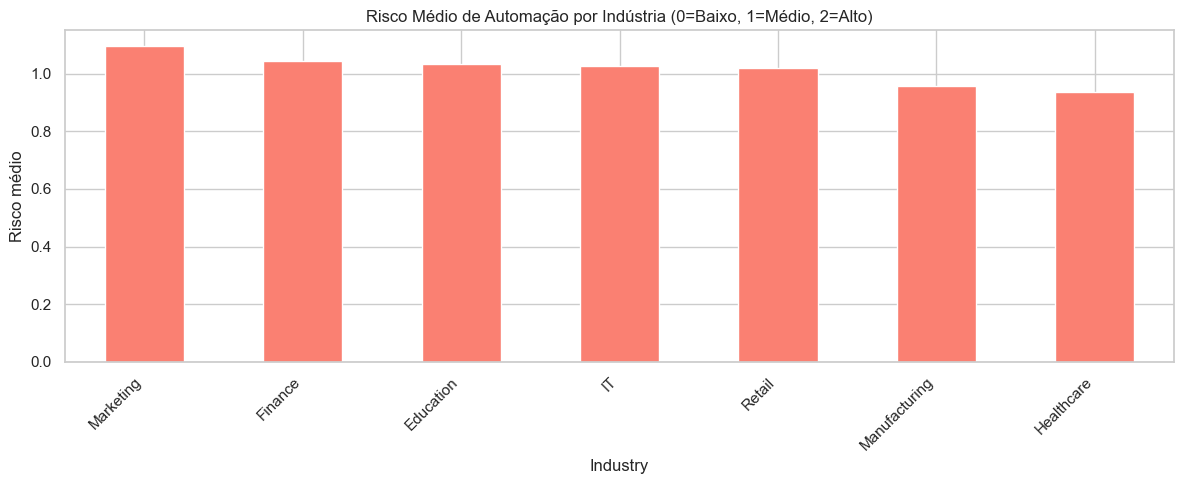

In [8]:
risk_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['Automation_Risk_Num'] = df['Automation_Risk'].map(risk_map)

risk_by_industry = (df.groupby('Industry')['Automation_Risk_Num']
                      .mean()
                      .sort_values(ascending=False))

plt.figure(figsize=(12, 5))
risk_by_industry.plot(kind='bar', color='salmon', edgecolor='white')
plt.title('Risco Médio de Automação por Indústria (0=Baixo, 1=Médio, 2=Alto)')
plt.ylabel('Risco médio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

df.drop(columns=['Automation_Risk_Num'], inplace=True)

## 5. Impacto no Salário por Status do Emprego

/var/folders/bp/vgg7l59507d7qlq8jzdh7_rw0000gn/T/ipykernel_68149/2489781988.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Job_Status', y='Salary_Change_%', palette='RdYlGn', ax=axes[0])
/var/folders/bp/vgg7l59507d7qlq8jzdh7_rw0000gn/T/ipykernel_68149/2489781988.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Job_Status', y='Job_Satisfaction', palette='Blues', ax=axes[1])


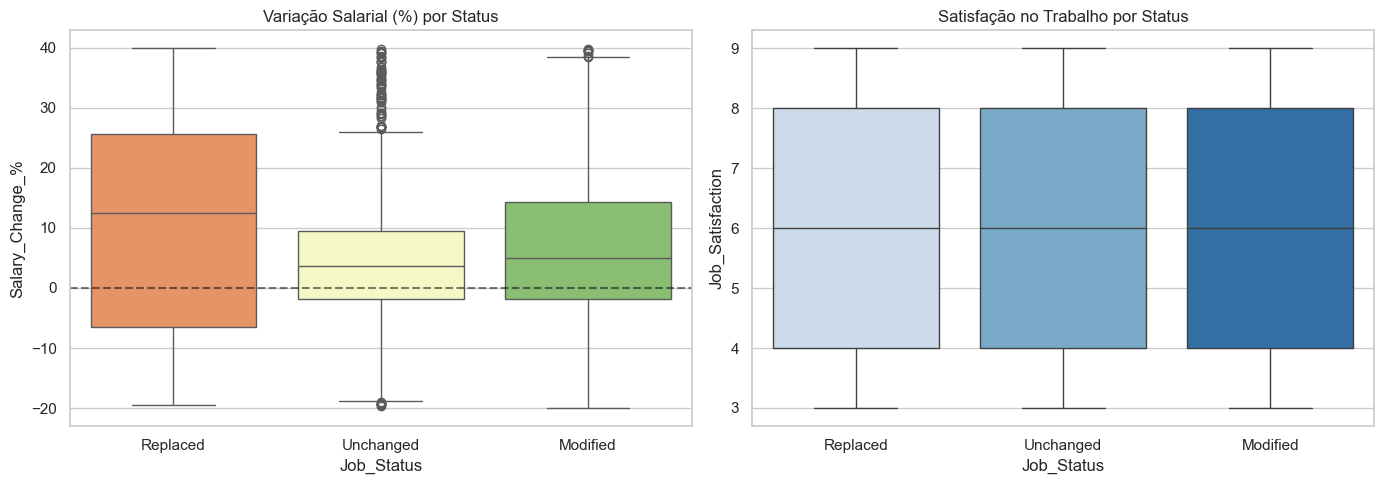

In [9]:
df['Salary_Change_%'] = ((df['Salary_After_AI'] - df['Salary_Before_AI']) / df['Salary_Before_AI']) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Job_Status', y='Salary_Change_%', palette='RdYlGn', ax=axes[0])
axes[0].set_title('Variação Salarial (%) por Status')
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)

sns.boxplot(data=df, x='Job_Status', y='Job_Satisfaction', palette='Blues', ax=axes[1])
axes[1].set_title('Satisfação no Trabalho por Status')

plt.tight_layout()
plt.show()

df.drop(columns=['Salary_Change_%'], inplace=True)

## 6. Correlação entre variáveis numéricas

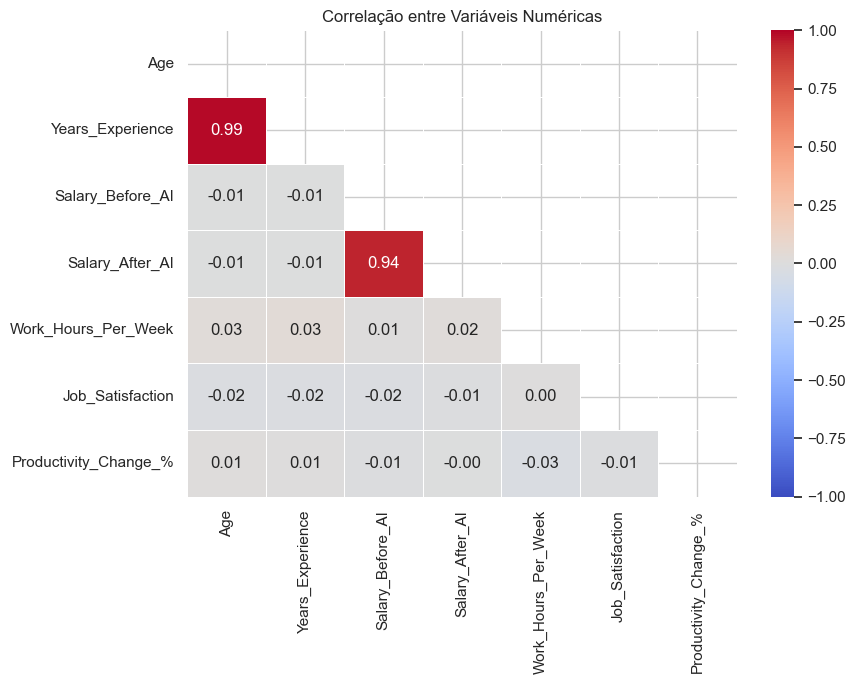

In [10]:
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlação entre Variáveis Numéricas')
plt.tight_layout()
plt.show()

## 7. Risco de Automação por Escolaridade

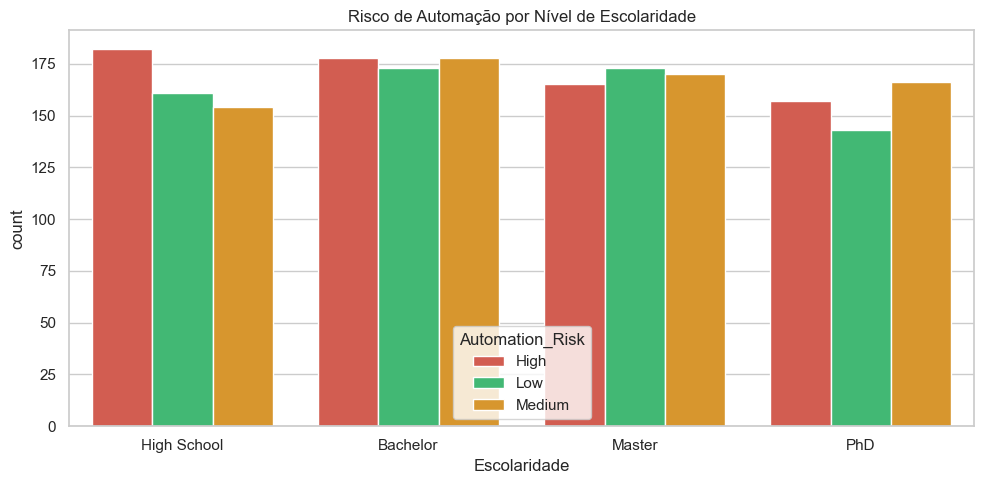

In [11]:
edu_order = ['High School', 'Bachelor', 'Master', 'PhD']

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Education_Level', hue='Automation_Risk',
              order=edu_order, palette={'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'})
plt.title('Risco de Automação por Nível de Escolaridade')
plt.xlabel('Escolaridade')
plt.tight_layout()
plt.show()

## Conclusões da EDA

- **Risco de automação** varia bastante entre indústrias — candidato ideal para separar clusters
- **Salário** e **satisfação** têm padrão distinto entre `Replaced`, `Modified` e `Unchanged`
- Variáveis como `Age`, `Education_Level` e `AI_Adoption_Level` têm baixa correlação linear entre si — cada uma agrega informação independente ao clustering
- Próximo passo: pré-processamento em `clustering_02_preprocessing.ipynb`